In [15]:
#created a dataset
import pandas as pd
import numpy as np

file_path = r"C:\Users\DELL\Downloads\loan_detection.csv"  # Update with your actual username

df = pd.read_csv(file_path)
print(df.head())


   age  campaign  pdays  previous  no_previous_contact  not_working  \
0   56         1    999         0                    1            0   
1   57         1    999         0                    1            0   
2   37         1    999         0                    1            0   
3   40         1    999         0                    1            0   
4   56         1    999         0                    1            0   

   job_admin.  job_blue-collar  job_entrepreneur  job_housemaid  ...  \
0           0                0                 0              1  ...   
1           0                0                 0              0  ...   
2           0                0                 0              0  ...   
3           1                0                 0              0  ...   
4           0                0                 0              0  ...   

   month_sep  day_of_week_fri  day_of_week_mon  day_of_week_thu  \
0          0                0                1                0   
1     

In [16]:
#import libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [17]:
#Load the Dataset
# Replace with the path to your CSV file
data = pd.read_csv(file_path)
print(data.head())

   age  campaign  pdays  previous  no_previous_contact  not_working  \
0   56         1    999         0                    1            0   
1   57         1    999         0                    1            0   
2   37         1    999         0                    1            0   
3   40         1    999         0                    1            0   
4   56         1    999         0                    1            0   

   job_admin.  job_blue-collar  job_entrepreneur  job_housemaid  ...  \
0           0                0                 0              1  ...   
1           0                0                 0              0  ...   
2           0                0                 0              0  ...   
3           1                0                 0              0  ...   
4           0                0                 0              0  ...   

   month_sep  day_of_week_fri  day_of_week_mon  day_of_week_thu  \
0          0                0                1                0   
1     

In [20]:
from sklearn.preprocessing import LabelEncoder

# Check for missing values
print(data.isnull().sum())

# Fill missing values (e.g., median for numerical, mode for categorical)
data.fillna(data.median(numeric_only=True), inplace=True)
data.fillna(data.mode().iloc[0], inplace=True)

# Encode categorical variables
label_encoder = LabelEncoder()
for column in data.select_dtypes(include=['object']).columns:
    data[column] = label_encoder.fit_transform(data[column])

print(data.info())



age                              0
campaign                         0
pdays                            0
previous                         0
no_previous_contact              0
not_working                      0
job_admin.                       0
job_blue-collar                  0
job_entrepreneur                 0
job_housemaid                    0
job_management                   0
job_retired                      0
job_self-employed                0
job_services                     0
job_student                      0
job_technician                   0
job_unemployed                   0
job_unknown                      0
marital_divorced                 0
marital_married                  0
marital_single                   0
marital_unknown                  0
education_basic.4y               0
education_basic.6y               0
education_basic.9y               0
education_high.school            0
education_illiterate             0
education_professional.course    0
education_university

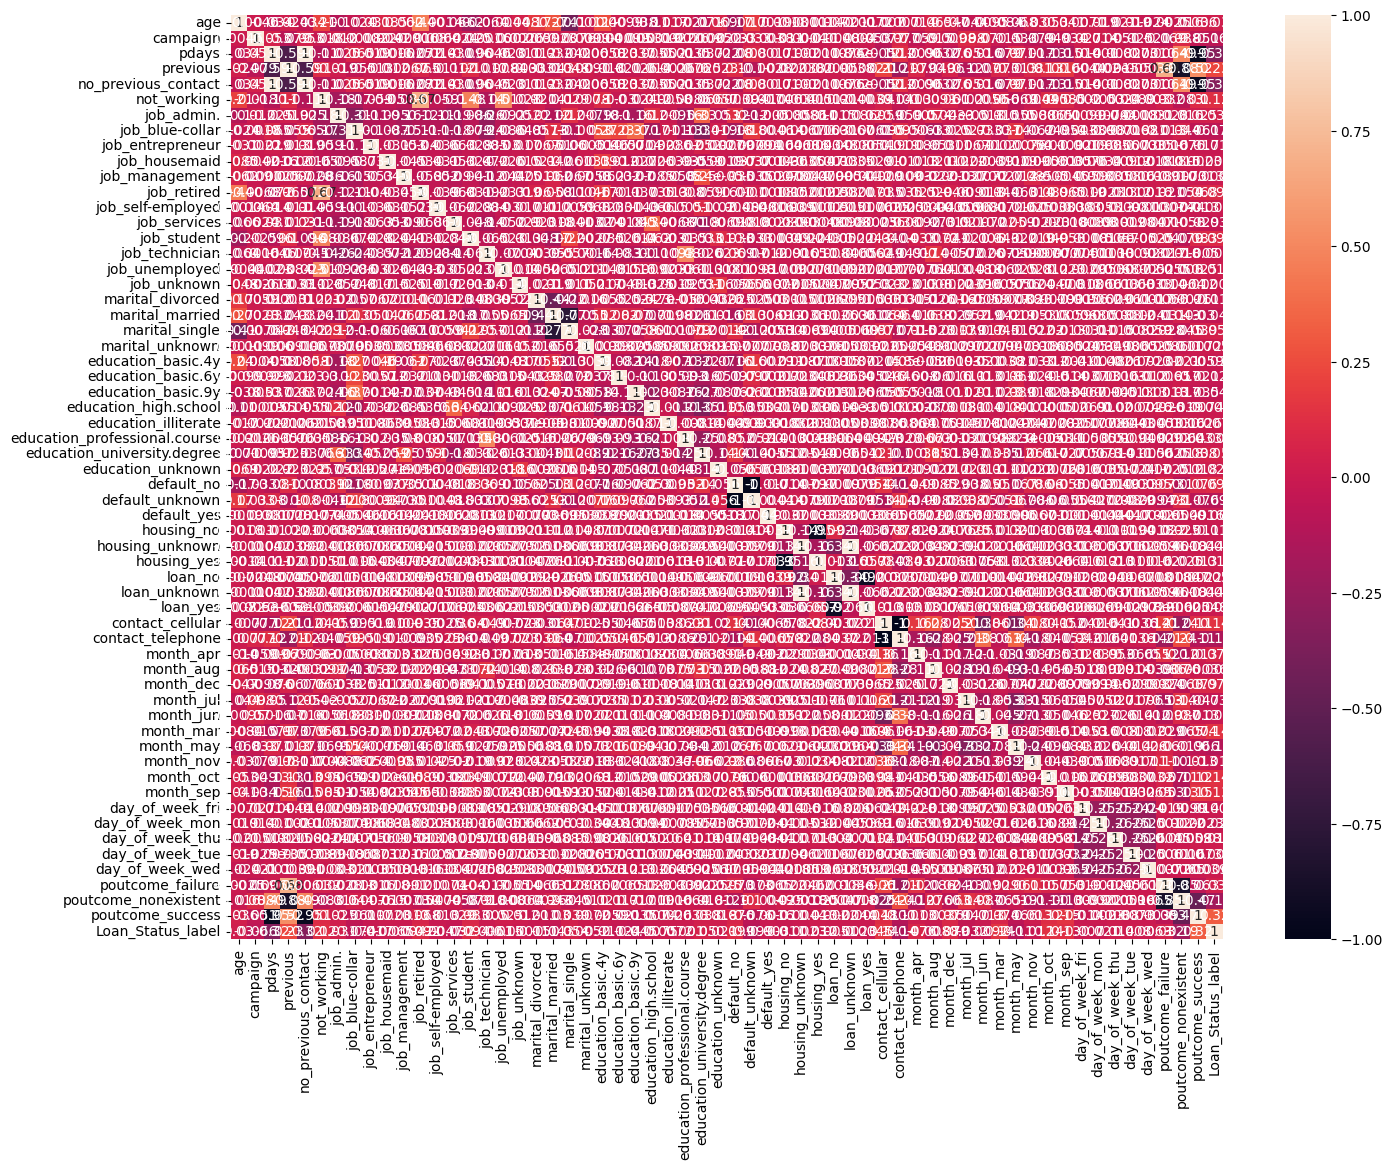

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size (adjust width and height to make it smaller)
plt.figure(figsize=(16, 12))  # Adjust the size as needed

# Correlation matrix
sns.heatmap(data.corr(), annot=True)

# Show the plot
plt.show()

# Drop irrelevant columns if necessary (e.g., IDs)
data = data.drop(columns=["Loan_ID"], errors='ignore')



In [23]:
# Check column names
print("Column names in dataset:", data.columns)

# Check for any extra spaces in column names
data.columns = data.columns.str.strip()  # Remove leading/trailing spaces

# Verify again
if "Loan_Status" not in data.columns:
    print("Error: 'Loan_Status' column not found!")
else:
    # Proceed with data splitting
    X = data.drop("Loan_Status", axis=1)
    y = data["Loan_Status"]

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print("Data successfully split!")


Column names in dataset: Index(['age', 'campaign', 'pdays', 'previous', 'no_previous_contact',
       'not_working', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_divorced', 'marital_married', 'marital_single',
       'marital_unknown', 'education_basic.4y', 'education_basic.6y',
       'education_basic.9y', 'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'education_unknown', 'default_no', 'default_unknown', 'default_yes',
       'housing_no', 'housing_unknown', 'housing_yes', 'loan_no',
       'loan_unknown', 'loan_yes', 'contact_cellular', 'contact_telephone',
       'month_apr', 'month_aug', 'month_dec', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'day_of_wee

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
file_path = r"C:\Users\DELL\Downloads\loan_detection.csv"  # Update with your actual username

df = pd.read_csv(file_path)

try:
    data = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
    
    # Ensure 'Loan_Status' column exists
    if "Loan_Status_label" not in data.columns:
        print("Error: 'Loan_Status' column not found in dataset.")
    else:
        # Define feature matrix (X) and target variable (y)
        X = data.drop(columns=["Loan_Status_label"], errors="ignore")  
        y = data["Loan_Status_label"]

        # Handle missing values
        X.fillna(X.median(numeric_only=True), inplace=True)

        # Split dataset
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Train model
        model = RandomForestClassifier(random_state=42)
        model.fit(X_train, y_train)

        # Make predictions
        y_pred = model.predict(X_test)

      
except FileNotFoundError:
    print(f"Error: File '{file_path}' not found. Please check the file path.")
except Exception as e:
    print(f"An error occurred: {e}")


Dataset loaded successfully!


In [35]:
#Evaluate the Model
# Evaluate model performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8871085214857976
Confusion Matrix:
 [[7074  229]
 [ 701  234]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.97      0.94      7303
           1       0.51      0.25      0.33       935

    accuracy                           0.89      8238
   macro avg       0.71      0.61      0.64      8238
weighted avg       0.86      0.89      0.87      8238



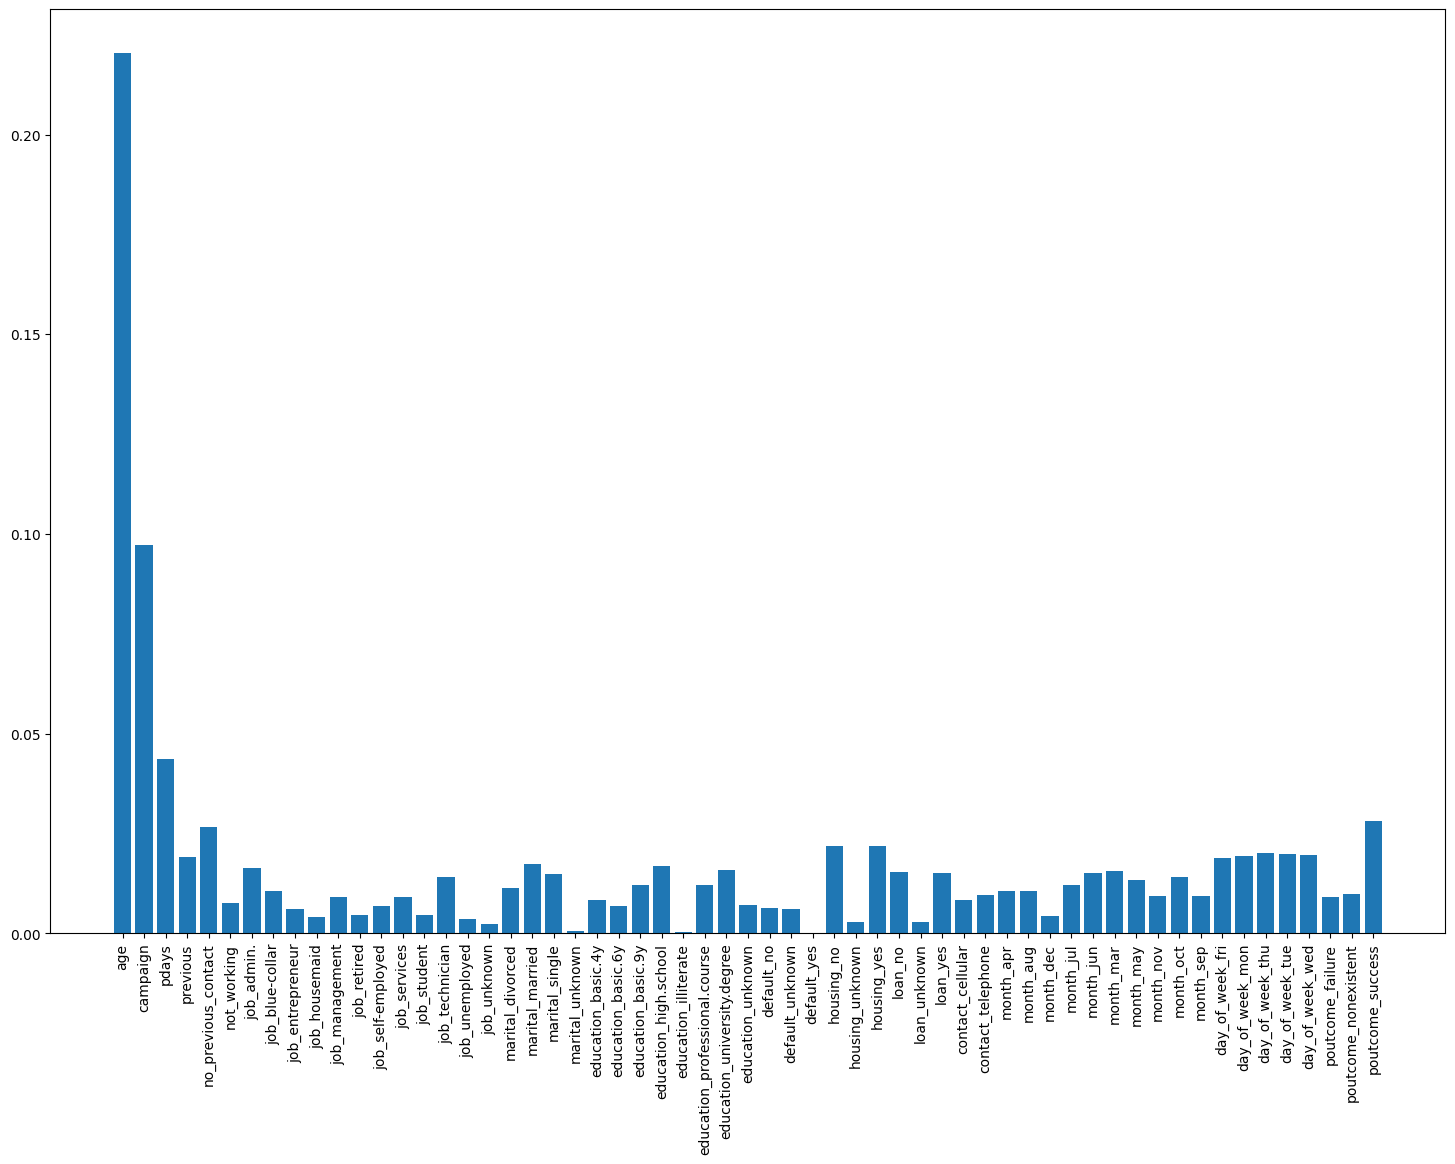

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a RandomForest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Plot feature importance
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 12))  # Adjust the size as needed
importance = model.feature_importances_
plt.bar(X.columns, importance)
plt.xticks(rotation=90)
plt.show()


